# CNNs for radiology images

In this notebook we will apply our new CNN knowledge to classify medical images. For this, we use a chest X-ray dataset from [MedMNIST](https://medmnist.com/). Here, we want to classify patients into healthy and pneumonia cases. It was originally derived from a larger pediatric chest X-ray dataset.

Goals:
- load X-ray data
- build and train CNN for pneumonia classification
- evaluate the model
- have a first look at explainability

In [1]:
from google.colab import ai
response = ai.generate_text("Tell me what AI you are and can you help me with coding problems?")
print(response)

Hello!

I am a large language model, trained by Google. My purpose is to assist with a wide range of tasks by processing information and generating human-like text based on the vast amount of data I've been trained on. I don't have personal experiences, consciousness, or feelings; I'm an AI designed to communicate and provide information.

And yes, absolutely! **I can definitely help you with coding problems.**

Here's how I can assist you:

*   **Explaining Concepts:** I can break down complex programming concepts, algorithms, data structures, and design patterns.
*   **Writing Code Snippets:** I can generate code snippets, functions, or even small programs in various programming languages (Python, JavaScript, Java, C++, Ruby, Go, etc.) based on your requirements.
*   **Debugging Assistance:** If you have an error, you can share your code and the error message, and I can help you identify the potential cause and suggest solutions.
*   **Code Review and Improvement:** I can look at you

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


## 1) Load MedMNIST datset

We use the `medmnist` package, which provides programmatic access to MedMNIST cohorts.

In [3]:
!pip install medmnist # should take around 2-3 min
import medmnist
from medmnist import INFO

In [4]:
data = "pneumoniamnist"

info = INFO[data]
DataClass = getattr(medmnist, info["python_class"])

print(info["task"])
print(info["label"])

transform = transforms.Compose([
    transforms.ToTensor()
])

binary-class
{'0': 'normal', '1': 'pneumonia'}


## 3) Train/validation/test split

In [5]:
train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset   = DataClass(split="val", transform=transform, download=True)
test_dataset  = DataClass(split="test", transform=transform, download=True)

print(len(train_dataset), len(val_dataset), len(test_dataset))

4708 524 624


Lets have a look at some example images. As you can see the images are very pixelated (28x28 pixels). This is of course not the resulution used in clinical practice.

/tmp/ipykernel_1796/2609169082.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(label)])


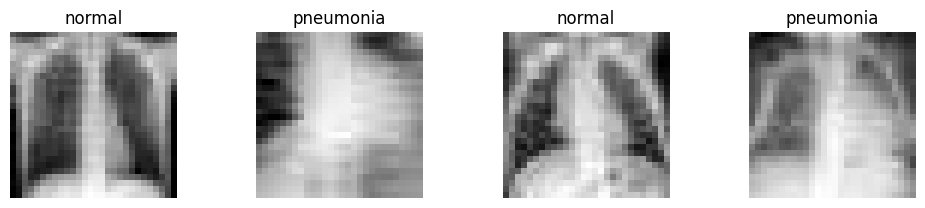

In [6]:
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]

plt.figure(figsize=(10, 4))
for i in range(4):
    img, label = train_dataset[i+5]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[int(label)])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4) Define a CNN

In [8]:

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
device = "cuda"
model = CNN().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 5) Training loop



In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.squeeze().long().to(device)

        with torch.set_grad_enabled(optimizer is not None):
            logits = model(x)
            loss = criterion(logits, y)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [11]:
num_epochs = 30

history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

Epoch 1/30 | train_loss=0.5752 | train_acc=0.7421 | val_loss=0.5576 | val_acc=0.7424
Epoch 2/30 | train_loss=0.5262 | train_acc=0.7421 | val_loss=0.4907 | val_acc=0.7424
Epoch 3/30 | train_loss=0.4323 | train_acc=0.7789 | val_loss=0.4200 | val_acc=0.7996
Epoch 4/30 | train_loss=0.3338 | train_acc=0.8626 | val_loss=0.2975 | val_acc=0.8760
Epoch 5/30 | train_loss=0.2677 | train_acc=0.8927 | val_loss=0.2878 | val_acc=0.8721
Epoch 6/30 | train_loss=0.2516 | train_acc=0.8910 | val_loss=0.2846 | val_acc=0.8836
Epoch 7/30 | train_loss=0.2479 | train_acc=0.8985 | val_loss=0.2274 | val_acc=0.8950
Epoch 8/30 | train_loss=0.2275 | train_acc=0.9025 | val_loss=0.2776 | val_acc=0.8874
Epoch 9/30 | train_loss=0.2204 | train_acc=0.9059 | val_loss=0.2235 | val_acc=0.9046
Epoch 10/30 | train_loss=0.2076 | train_acc=0.9127 | val_loss=0.2190 | val_acc=0.9008
Epoch 11/30 | train_loss=0.2120 | train_acc=0.9121 | val_loss=0.2144 | val_acc=0.9084
Epoch 12/30 | train_loss=0.2235 | train_acc=0.9051 | val_loss=0

## 6) Plot reconstruction loss

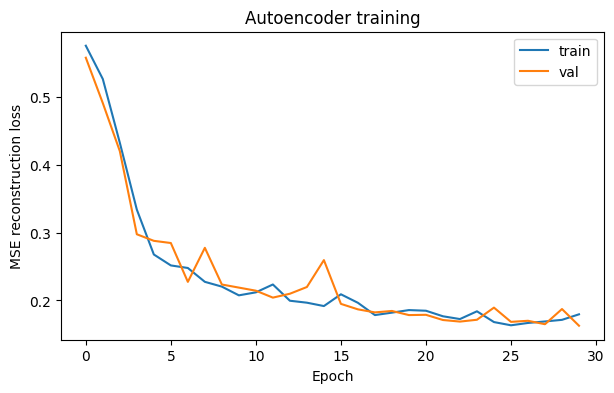

In [12]:
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("Autoencoder training")
plt.legend()
plt.show()

In [13]:
model.eval()

all_probs = []
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.squeeze().long().to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

ROC AUC: 0.9496


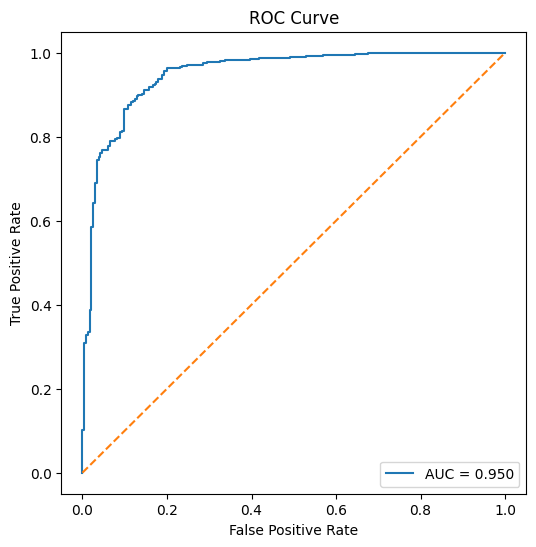

In [14]:
roc_auc = roc_auc_score(all_targets, all_probs)
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

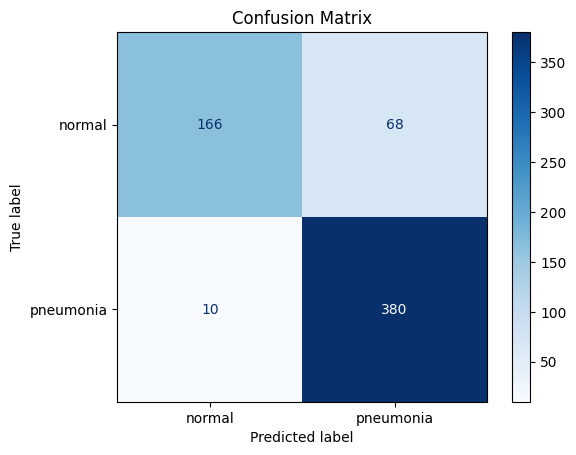

Accuracy : 0.8750
Precision: 0.8482
Recall   : 0.9744
F1 score : 0.9069
ROC AUC  : 0.9496

Classification report:

              precision    recall  f1-score   support

      normal       0.94      0.71      0.81       234
   pneumonia       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.88      0.88      0.87       624



In [15]:
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal", "pneumonia"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

acc = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification report:\n")
print(classification_report(all_targets, all_preds, target_names=["normal", "pneumonia"]))

## (Explainability) Grad-CAM
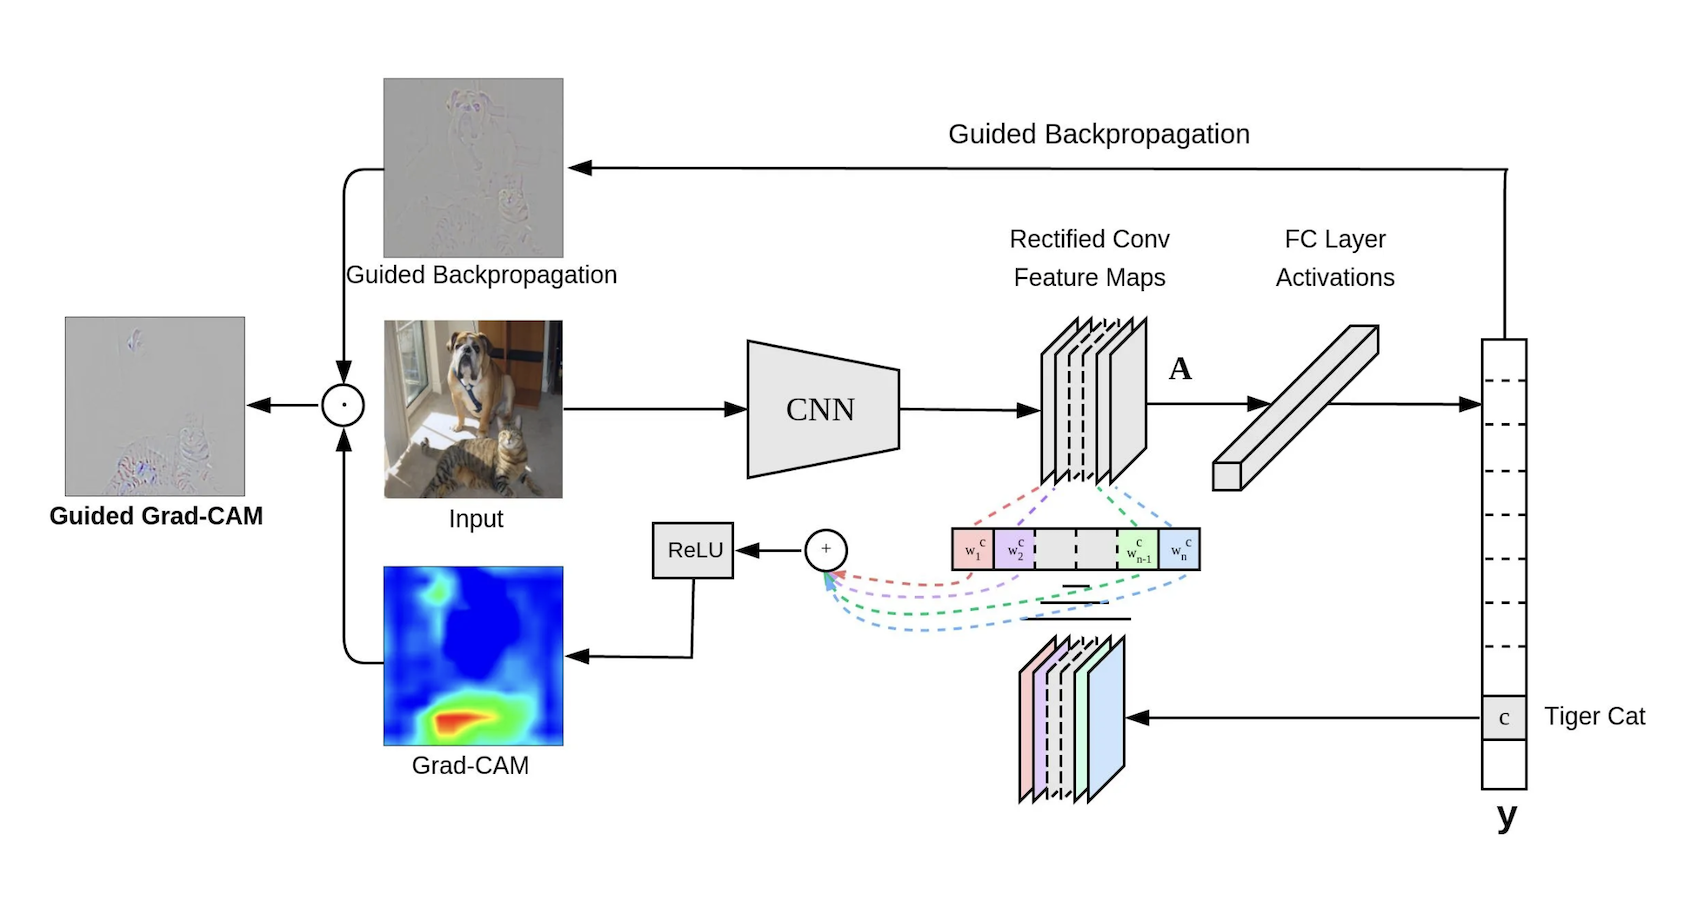

**Grad-CAM** is an explainability method that helps us understand which **image regions** were most **important** for a model’s prediction. This can help us check whether the network is using clinically meaningful structures or whether it is relying on irrelevant patterns in the image.

The basic idea of Grad-CAM is to combine the **feature maps** of a convolutional layer with the **gradients** of the predicted class. First, we pass an image through the network and select the output score for the class of interest. Then we compute the gradient of this score with respect to the feature maps in the last convolutional layer. These gradients tell us which channels were most important for the prediction. By averaging the gradients over space, we obtain weights for each feature map. The weighted combination of these feature maps produces a coarse heatmap that highlights influential regions in the image.

In [16]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[:, class_idx]
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

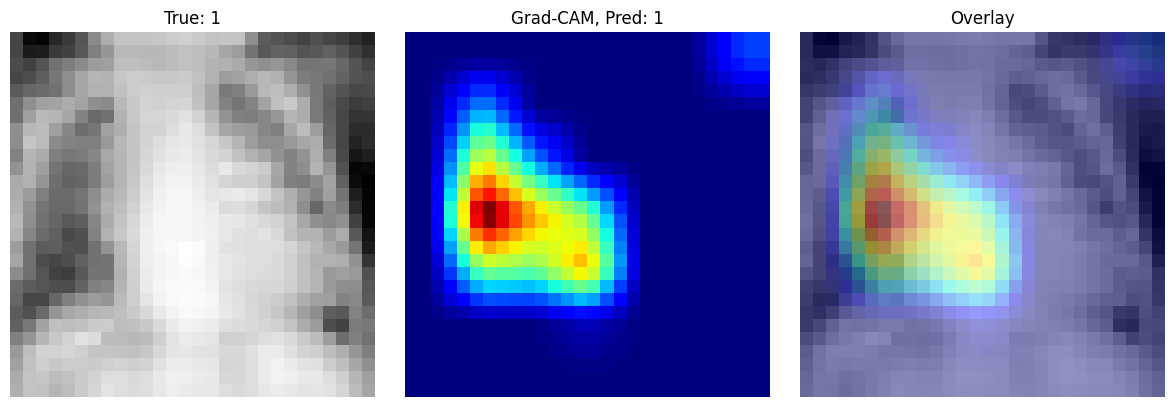

In [18]:
target_layer = model.features[6]
gradcam = GradCAM(model, target_layer=model.features[6])

img, label = test_dataset[0]
x = img.unsqueeze(0).to(device)

cam, pred_class = gradcam.generate(x)

img_np = img.squeeze().cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title(f"True: {label.item()}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM, Pred: {pred_class}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()